# Global 850 hPa Wind Direction

This notebook uses a 12-hour global ERA5 slice to inspect 850 hPa wind speed and direction. It plots wind speed as shading and wind vectors as arrows, then compares hour-to-hour changes using a few diagnostics that are common in synoptic meteorology: vector wind tendency, veering/backing, and hodographs.

## Data

- Pressure levels: ERA5 `u_component_of_wind` and `v_component_of_wind` at 850 hPa.
- Single levels: ERA5 `surface_pressure`, used to blank cells where the 850 hPa pressure surface is below terrain.
- Window: 2017-03-14 00:00-11:00 UTC, hourly.
- Area: global ERA5 grid from 89 S to 89 N.

In [1]:
from pathlib import Path
import os


def find_project_root(start):
    for path in [start, *start.parents]:
        if (path / "AGENTS.md").exists():
            return path
    return start


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
TMP_DIR = PROJECT_ROOT / "tmp" / "global-850-wind-direction"
DATA_DIR = PROJECT_ROOT / "data"
TMP_DIR.mkdir(parents=True, exist_ok=True)

os.environ.setdefault("MPLCONFIGDIR", str(TMP_DIR / "matplotlib"))
os.environ.setdefault("XDG_CACHE_HOME", str(TMP_DIR / "cache"))
os.environ.setdefault("CARTOPY_DATA_DIR", str(TMP_DIR / "cartopy"))

WIND_PATH = DATA_DIR / "era5_global_850_uv_2017-03-14_00-11.nc"
SURFACE_PRESSURE_PATH = DATA_DIR / "era5_global_surface_pressure_2017-03-14_00-11.nc"
PLOT_DIR = TMP_DIR / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Wind file: {WIND_PATH}")
print(f"Surface pressure file: {SURFACE_PRESSURE_PATH}")
print(f"PNG output directory: {PLOT_DIR}")

Wind file: /home/dmmsp/Projects/observations-vs-forecasts/data/era5_global_850_uv_2017-03-14_00-11.nc
Surface pressure file: /home/dmmsp/Projects/observations-vs-forecasts/data/era5_global_surface_pressure_2017-03-14_00-11.nc
PNG output directory: /home/dmmsp/Projects/observations-vs-forecasts/tmp/global-850-wind-direction/plots


In [2]:
import math
from html import escape

import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from IPython.display import HTML, display
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import numpy as np
import pandas as pd
import xarray as xr

cartopy.config["data_dir"] = str(TMP_DIR / "cartopy")

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 140,
        "font.size": 9,
        "axes.titlesize": 10,
        "axes.labelsize": 9,
    }
)

ARROW_STRIDE = 16
CHANGE_ARROW_STRIDE = 16
PRESSURE_LEVEL_PA = 85000.0
PLATE_CARREE = ccrs.PlateCarree()
MAP_PROJECTION = ccrs.PlateCarree()

if not WIND_PATH.exists():
    raise FileNotFoundError(WIND_PATH)
if not SURFACE_PRESSURE_PATH.exists():
    raise FileNotFoundError(SURFACE_PRESSURE_PATH)

## Load And Derive Fields

In [3]:
wind_ds = xr.open_dataset(WIND_PATH, engine="netcdf4")
surface_ds = xr.open_dataset(SURFACE_PRESSURE_PATH, engine="netcdf4")

u = wind_ds["u"].sel(pressure_level=850).squeeze(drop=True).load()
v = wind_ds["v"].sel(pressure_level=850).squeeze(drop=True).load()
surface_pressure = surface_ds["sp"].squeeze(drop=True).load()

speed = xr.apply_ufunc(np.hypot, u, v).rename("wind_speed")

# Meteorological wind direction is the direction the wind is coming from,
# measured clockwise from north. Quiver arrows below point toward the flow.
wind_from_deg = ((270.0 - np.degrees(np.arctan2(v, u))) % 360.0).rename("wind_from_deg")
valid_mask_850 = surface_pressure >= PRESSURE_LEVEL_PA
masked_fraction = (100.0 * (~valid_mask_850).mean(("latitude", "longitude"))).rename("masked_fraction_pct")

time_values = pd.to_datetime(u.valid_time.values)
time_labels = [time.strftime("%H:%M UTC") for time in time_values]
time_file_labels = [time.strftime("%Y%m%d_%H%M") for time in time_values]
change_labels = [
    f"{time_values[i - 1].strftime('%H')} to {time_values[i].strftime('%H')} UTC"
    for i in range(1, len(time_values))
]
change_file_labels = [
    f"{time_values[i - 1].strftime('%Y%m%d_%H%M')}-{time_values[i].strftime('%H%M')}"
    for i in range(1, len(time_values))
]

summary = pd.DataFrame(
    {
        "valid_time_utc": [time.strftime("%Y-%m-%d %H:%M") for time in time_values],
        "global_mean_speed_mps": speed.mean(("latitude", "longitude")).values,
        "p95_speed_mps": speed.quantile(0.95, dim=("latitude", "longitude")).values,
        "under_surface_pct": masked_fraction.values,
    }
)
summary.round(2)

,valid_time_utc,global_mean_speed_mps,p95_speed_mps,under_surface_pct
0,2017-03-14 00:00,8.52,20.35,10.15
1,2017-03-14 01:00,8.53,20.35,10.15
2,2017-03-14 02:00,8.54,20.29,10.15
3,2017-03-14 03:00,8.55,20.24,10.15
4,2017-03-14 04:00,8.56,20.24,10.14
5,2017-03-14 05:00,8.57,20.27,10.14
6,2017-03-14 06:00,8.58,20.33,10.14
7,2017-03-14 07:00,8.58,20.37,10.14
8,2017-03-14 08:00,8.59,20.38,10.14
9,2017-03-14 09:00,8.60,20.36,10.15


In [4]:
lon = u.longitude.values
lat = u.latitude.values
extent = [float(lon.min()), float(lon.max()), float(lat.min()), float(lat.max())]

speed_cmap = plt.get_cmap("plasma").copy()
speed_cmap.set_bad((1, 1, 1, 0))
speed_vmax = float(np.nanpercentile(speed.values, 99.2))
speed_levels_label = f"850 hPa wind speed (m s$^{{-1}}$), 0-{speed_vmax:.0f}"
saved_pngs = []


def setup_global_axis(ax):
    ax.set_global()
    ax.set_extent([-180, 180, -89, 89], crs=PLATE_CARREE)
    gridliner = ax.gridlines(
        crs=PLATE_CARREE,
        draw_labels=True,
        xlocs=np.arange(-180, 181, 60),
        ylocs=np.arange(-60, 61, 30),
        linewidth=0.45,
        color="0.78",
        alpha=0.8,
    )
    gridliner.top_labels = False
    gridliner.right_labels = False
    ax.plot([-180, 180], [0, 0], color="0.25", linewidth=0.5, transform=PLATE_CARREE)


def draw_land_borders(ax):
    ax.coastlines(resolution="110m", linewidth=0.75, color="0.02", zorder=20)
    ax.add_feature(cfeature.BORDERS.with_scale("110m"), linewidth=0.5, edgecolor="0.02", zorder=20)


def draw_speed_image(ax, field, title, cmap=speed_cmap, vmin=0.0, vmax=None, norm=None):
    image = ax.pcolormesh(
        lon,
        lat,
        field,
        transform=PLATE_CARREE,
        cmap=cmap,
        vmin=vmin if norm is None else None,
        vmax=vmax if norm is None else None,
        norm=norm,
        shading="nearest",
        rasterized=True,
    )
    setup_global_axis(ax)
    ax.set_title(title)
    return image


def draw_quiver(ax, u_field, v_field, stride, scale, color="black", alpha=0.75, width=0.0010):
    x = lon[::stride]
    y = lat[::stride]
    uu = np.ma.masked_invalid(np.asarray(u_field)[::stride, ::stride])
    vv = np.ma.masked_invalid(np.asarray(v_field)[::stride, ::stride])
    ax.quiver(
        x,
        y,
        uu,
        vv,
        transform=PLATE_CARREE,
        angles="uv",
        scale_units="width",
        scale=scale,
        width=width,
        headwidth=3.0,
        headlength=3.8,
        headaxislength=3.4,
        pivot="middle",
        color=color,
        alpha=alpha,
    )


def make_map_figure():
    return plt.subplots(
        figsize=(12.8, 6.8),
        constrained_layout=True,
        subplot_kw={"projection": MAP_PROJECTION},
    )


def save_current_figure(fig, filename):
    path = PLOT_DIR / filename
    fig.savefig(path, dpi=115, bbox_inches="tight")
    saved_pngs.append(path)
    return path


def show_saved_png(path, title):
    relative_path = path.relative_to(PROJECT_ROOT).as_posix()
    display(
        HTML(
            f'<h4>{escape(title)}</h4>'
            f'<img src="{escape(relative_path)}" style="width: 100%; max-width: 1280px;">'
        )
    )

## Wind Speed And Direction

In [5]:
for index in range(len(time_values)):
    fig, ax = make_map_figure()
    image = draw_speed_image(
        ax,
        speed.isel(valid_time=index).values,
        f"Global 850 hPa Wind Direction And Speed | {time_labels[index]}",
        vmax=speed_vmax,
    )
    draw_quiver(
        ax,
        u.isel(valid_time=index).values,
        v.isel(valid_time=index).values,
        stride=ARROW_STRIDE,
        scale=950,
        alpha=0.62,
        width=0.00075,
    )
    draw_land_borders(ax)
    fig.colorbar(image, ax=ax, shrink=0.78, pad=0.02, label=speed_levels_label)
    title = f"Global 850 hPa Wind Direction And Speed | {time_labels[index]}"
    out = save_current_figure(fig, f"850_wind_speed_direction_{time_file_labels[index]}.png")
    print(out)
    plt.close(fig)
    show_saved_png(out, title)

/home/dmmsp/Projects/observations-vs-forecasts/tmp/global-850-wind-direction/plots/850_wind_speed_direction_20170314_0000.png


/home/dmmsp/Projects/observations-vs-forecasts/tmp/global-850-wind-direction/plots/850_wind_speed_direction_20170314_0100.png


/home/dmmsp/Projects/observations-vs-forecasts/tmp/global-850-wind-direction/plots/850_wind_speed_direction_20170314_0200.png


/home/dmmsp/Projects/observations-vs-forecasts/tmp/global-850-wind-direction/plots/850_wind_speed_direction_20170314_0300.png


/home/dmmsp/Projects/observations-vs-forecasts/tmp/global-850-wind-direction/plots/850_wind_speed_direction_20170314_0400.png


...

/home/dmmsp/Projects/observations-vs-forecasts/tmp/global-850-wind-direction/plots/850_wind_speed_direction_20170314_0700.png


/home/dmmsp/Projects/observations-vs-forecasts/tmp/global-850-wind-direction/plots/850_wind_speed_direction_20170314_0800.png


/home/dmmsp/Projects/observations-vs-forecasts/tmp/global-850-wind-direction/plots/850_wind_speed_direction_20170314_0900.png


/home/dmmsp/Projects/observations-vs-forecasts/tmp/global-850-wind-direction/plots/850_wind_speed_direction_20170314_1000.png


/home/dmmsp/Projects/observations-vs-forecasts/tmp/global-850-wind-direction/plots/850_wind_speed_direction_20170314_1100.png


## Hour-To-Hour Change Idea 1: Speed Tendency With Vector Change

Operationally, a direct vector wind tendency map is useful because it separates where the wind is simply strengthening or weakening from where the actual wind vector is rotating or shifting. Shading shows the hour-to-hour speed change, and arrows show the vector change `(du, dv)`.

In [6]:
speed_change = speed.diff("valid_time").rename("speed_change")
du_change = u.diff("valid_time").rename("du_change")
dv_change = v.diff("valid_time").rename("dv_change")

change_abs = float(np.nanpercentile(np.abs(speed_change.values), 99.0))
speed_change_norm = TwoSlopeNorm(vmin=-change_abs, vcenter=0.0, vmax=change_abs)

for index in range(speed_change.sizes["valid_time"]):
    fig, ax = make_map_figure()
    image = draw_speed_image(
        ax,
        speed_change.isel(valid_time=index).values,
        f"850 hPa Speed Change And Vector-Wind Tendency | {change_labels[index]}",
        cmap="RdBu_r",
        norm=speed_change_norm,
    )
    draw_quiver(
        ax,
        du_change.isel(valid_time=index).values,
        dv_change.isel(valid_time=index).values,
        stride=CHANGE_ARROW_STRIDE,
        scale=260,
        color="0.05",
        alpha=0.72,
        width=0.00095,
    )
    draw_land_borders(ax)
    fig.colorbar(image, ax=ax, shrink=0.78, pad=0.02, label="Speed change (m s$^{-1}$ h$^{-1}$)")
    title = f"850 hPa Speed Change And Vector-Wind Tendency | {change_labels[index]}"
    out = save_current_figure(fig, f"850_wind_speed_vector_change_{change_file_labels[index]}.png")
    print(out)
    plt.close(fig)
    show_saved_png(out, title)

/home/dmmsp/Projects/observations-vs-forecasts/tmp/global-850-wind-direction/plots/850_wind_speed_vector_change_20170314_0000-0100.png


/home/dmmsp/Projects/observations-vs-forecasts/tmp/global-850-wind-direction/plots/850_wind_speed_vector_change_20170314_0100-0200.png


/home/dmmsp/Projects/observations-vs-forecasts/tmp/global-850-wind-direction/plots/850_wind_speed_vector_change_20170314_0200-0300.png


/home/dmmsp/Projects/observations-vs-forecasts/tmp/global-850-wind-direction/plots/850_wind_speed_vector_change_20170314_0300-0400.png


/home/dmmsp/Projects/observations-vs-forecasts/tmp/global-850-wind-direction/plots/850_wind_speed_vector_change_20170314_0400-0500.png


...

/home/dmmsp/Projects/observations-vs-forecasts/tmp/global-850-wind-direction/plots/850_wind_speed_vector_change_20170314_0600-0700.png


/home/dmmsp/Projects/observations-vs-forecasts/tmp/global-850-wind-direction/plots/850_wind_speed_vector_change_20170314_0700-0800.png


/home/dmmsp/Projects/observations-vs-forecasts/tmp/global-850-wind-direction/plots/850_wind_speed_vector_change_20170314_0800-0900.png


/home/dmmsp/Projects/observations-vs-forecasts/tmp/global-850-wind-direction/plots/850_wind_speed_vector_change_20170314_0900-1000.png


/home/dmmsp/Projects/observations-vs-forecasts/tmp/global-850-wind-direction/plots/850_wind_speed_vector_change_20170314_1000-1100.png


## Hour-To-Hour Change Idea 2: Veering And Backing

Forecasters often describe directional changes as veering or backing. Positive values here mean the meteorological wind direction turned clockwise from the previous hour; negative values mean it turned counterclockwise. The calculation masks weak-wind grid cells where small vector noise can make direction changes look exaggerated.

In [7]:
dir_current = wind_from_deg.isel(valid_time=slice(1, None))
dir_previous = wind_from_deg.isel(valid_time=slice(None, -1)).assign_coords(valid_time=dir_current.valid_time)
direction_change = (((dir_current - dir_previous + 180.0) % 360.0) - 180.0).rename("direction_change_deg")

previous_speed = speed.isel(valid_time=slice(None, -1)).assign_coords(valid_time=dir_current.valid_time)
current_speed = speed.isel(valid_time=slice(1, None))
direction_change = direction_change.where((previous_speed >= 4.0) & (current_speed >= 4.0))

direction_cmap = plt.get_cmap("twilight_shifted").copy()
direction_cmap.set_bad((1, 1, 1, 0))
direction_norm = TwoSlopeNorm(vmin=-90.0, vcenter=0.0, vmax=90.0)

for index in range(direction_change.sizes["valid_time"]):
    fig, ax = make_map_figure()
    image = draw_speed_image(
        ax,
        direction_change.isel(valid_time=index).values,
        f"850 hPa Direction Change: Veering And Backing | {change_labels[index]}",
        cmap=direction_cmap,
        norm=direction_norm,
    )
    sc = speed_change.isel(valid_time=index).values[::4, ::4]
    xx = lon[::4]
    yy = lat[::4]
    ax.contour(
        xx,
        yy,
        sc,
        levels=[-6, -3, 3, 6],
        colors="0.15",
        linewidths=0.45,
        alpha=0.75,
        transform=PLATE_CARREE,
    )
    draw_land_borders(ax)
    fig.colorbar(image, ax=ax, shrink=0.78, pad=0.02, label="Direction change (degrees h$^{-1}$)")
    title = f"850 hPa Direction Change: Veering And Backing | {change_labels[index]}"
    out = save_current_figure(fig, f"850_wind_direction_change_{change_file_labels[index]}.png")
    print(out)
    plt.close(fig)
    show_saved_png(out, title)

/home/dmmsp/Projects/observations-vs-forecasts/tmp/global-850-wind-direction/plots/850_wind_direction_change_20170314_0000-0100.png


/home/dmmsp/Projects/observations-vs-forecasts/tmp/global-850-wind-direction/plots/850_wind_direction_change_20170314_0100-0200.png


/home/dmmsp/Projects/observations-vs-forecasts/tmp/global-850-wind-direction/plots/850_wind_direction_change_20170314_0200-0300.png


/home/dmmsp/Projects/observations-vs-forecasts/tmp/global-850-wind-direction/plots/850_wind_direction_change_20170314_0300-0400.png


/home/dmmsp/Projects/observations-vs-forecasts/tmp/global-850-wind-direction/plots/850_wind_direction_change_20170314_0400-0500.png


...

/home/dmmsp/Projects/observations-vs-forecasts/tmp/global-850-wind-direction/plots/850_wind_direction_change_20170314_0600-0700.png


/home/dmmsp/Projects/observations-vs-forecasts/tmp/global-850-wind-direction/plots/850_wind_direction_change_20170314_0700-0800.png


/home/dmmsp/Projects/observations-vs-forecasts/tmp/global-850-wind-direction/plots/850_wind_direction_change_20170314_0800-0900.png


/home/dmmsp/Projects/observations-vs-forecasts/tmp/global-850-wind-direction/plots/850_wind_direction_change_20170314_0900-1000.png


/home/dmmsp/Projects/observations-vs-forecasts/tmp/global-850-wind-direction/plots/850_wind_direction_change_20170314_1000-1100.png


## Hour-To-Hour Change Idea 3: Regional Hodographs

A hodograph is a compact way to see simultaneous direction and speed evolution. Each curve below is an area-weighted 850 hPa mean wind vector through the 12-hour window for a broad latitude band.

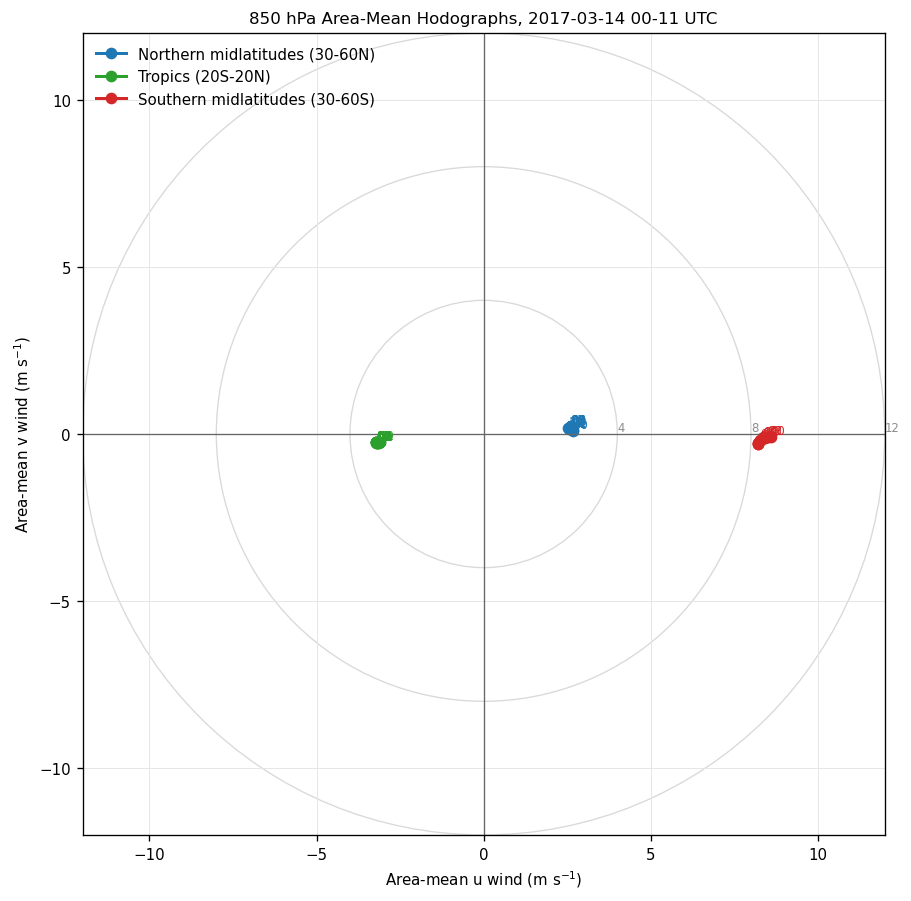

In [8]:
def latitude_slice(lat_min, lat_max):
    return slice(lat_max, lat_min)


def area_weighted_mean(da, lat_min, lat_max):
    subset = da.sel(latitude=latitude_slice(lat_min, lat_max))
    weights = np.cos(np.deg2rad(subset.latitude))
    return subset.weighted(weights).mean(("latitude", "longitude"))


regions = {
    "Northern midlatitudes (30-60N)": (30, 60),
    "Tropics (20S-20N)": (-20, 20),
    "Southern midlatitudes (30-60S)": (-60, -30),
}

fig, ax = plt.subplots(figsize=(8.2, 7.4), constrained_layout=True)
colors = ["tab:blue", "tab:green", "tab:red"]

max_axis = 0.0
for (name, (lat_min, lat_max)), color in zip(regions.items(), colors):
    mean_u = area_weighted_mean(u, lat_min, lat_max)
    mean_v = area_weighted_mean(v, lat_min, lat_max)
    ax.plot(mean_u, mean_v, marker="o", linewidth=1.8, color=color, label=name)
    for hour, x, y in zip(time_values.hour, mean_u.values, mean_v.values):
        ax.text(x, y, f"{hour:02d}", fontsize=7, color=color, ha="left", va="bottom")
    max_axis = max(max_axis, float(np.nanmax(np.abs(mean_u.values))), float(np.nanmax(np.abs(mean_v.values))))

limit = math.ceil((max_axis + 2.0) / 2.0) * 2.0
for radius in np.arange(4, max(limit, 4) + 4, 4):
    circle = plt.Circle((0, 0), radius, fill=False, color="0.85", linewidth=0.8)
    ax.add_patch(circle)
    ax.text(radius, 0, f"{radius:.0f}", color="0.55", fontsize=7, va="bottom")

ax.axhline(0, color="0.4", linewidth=0.8)
ax.axvline(0, color="0.4", linewidth=0.8)
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-limit, limit)
ax.set_ylim(-limit, limit)
ax.grid(color="0.9", linewidth=0.6)
ax.set_xlabel("Area-mean u wind (m s$^{-1}$)")
ax.set_ylabel("Area-mean v wind (m s$^{-1}$)")
ax.set_title("850 hPa Area-Mean Hodographs, 2017-03-14 00-11 UTC")
ax.legend(loc="upper left", frameon=False)
plt.show()

## Wind Speed And Direction With 850 hPa Below Ground Masked

In [9]:
u_masked = u.where(valid_mask_850)
v_masked = v.where(valid_mask_850)
speed_masked = speed.where(valid_mask_850)

for index in range(len(time_values)):
    fig, ax = make_map_figure()
    image = draw_speed_image(
        ax,
        speed_masked.isel(valid_time=index).values,
        f"Global 850 hPa Wind With Subsurface Cells Blank | {time_labels[index]} | masked {masked_fraction.isel(valid_time=index).item():.1f}%",
        vmax=speed_vmax,
    )
    draw_quiver(
        ax,
        u_masked.isel(valid_time=index).values,
        v_masked.isel(valid_time=index).values,
        stride=ARROW_STRIDE,
        scale=950,
        alpha=0.62,
        width=0.00075,
    )
    draw_land_borders(ax)
    fig.colorbar(image, ax=ax, shrink=0.78, pad=0.02, label=speed_levels_label)
    title = f"Global 850 hPa Wind With Subsurface Cells Blank | {time_labels[index]}"
    out = save_current_figure(fig, f"850_wind_speed_direction_masked_{time_file_labels[index]}.png")
    print(out)
    plt.close(fig)
    show_saved_png(out, title)

pd.DataFrame({"png": [str(path.relative_to(PROJECT_ROOT)) for path in saved_pngs]})

/home/dmmsp/Projects/observations-vs-forecasts/tmp/global-850-wind-direction/plots/850_wind_speed_direction_masked_20170314_0000.png


/home/dmmsp/Projects/observations-vs-forecasts/tmp/global-850-wind-direction/plots/850_wind_speed_direction_masked_20170314_0100.png


/home/dmmsp/Projects/observations-vs-forecasts/tmp/global-850-wind-direction/plots/850_wind_speed_direction_masked_20170314_0200.png


/home/dmmsp/Projects/observations-vs-forecasts/tmp/global-850-wind-direction/plots/850_wind_speed_direction_masked_20170314_0300.png


/home/dmmsp/Projects/observations-vs-forecasts/tmp/global-850-wind-direction/plots/850_wind_speed_direction_masked_20170314_0400.png


...

/home/dmmsp/Projects/observations-vs-forecasts/tmp/global-850-wind-direction/plots/850_wind_speed_direction_masked_20170314_0800.png


/home/dmmsp/Projects/observations-vs-forecasts/tmp/global-850-wind-direction/plots/850_wind_speed_direction_masked_20170314_0900.png


/home/dmmsp/Projects/observations-vs-forecasts/tmp/global-850-wind-direction/plots/850_wind_speed_direction_masked_20170314_1000.png


/home/dmmsp/Projects/observations-vs-forecasts/tmp/global-850-wind-direction/plots/850_wind_speed_direction_masked_20170314_1100.png


,png
0,tmp/global-850-wind-direction/plots/850_wind_s...
1,tmp/global-850-wind-direction/plots/850_wind_s...
2,tmp/global-850-wind-direction/plots/850_wind_s...
3,tmp/global-850-wind-direction/plots/850_wind_s...
4,tmp/global-850-wind-direction/plots/850_wind_s...
5,tmp/global-850-wind-direction/plots/850_wind_s...
6,tmp/global-850-wind-direction/plots/850_wind_s...
7,tmp/global-850-wind-direction/plots/850_wind_s...
8,tmp/global-850-wind-direction/plots/850_wind_s...
9,tmp/global-850-wind-direction/plots/850_wind_s...
